In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import numpy as np

from nexuskan import *
from nexuskan import KAN
from nexuskan import nexusKAN

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# grad test

$x_1 x_3 + x_2 x_5 + x_4$

in: 5, out: 2

In [3]:
def some_func_to_add_dim(x, out_dim):
    x_res = torch.unsqueeze(x, dim=2)
    for i in range(out_dim - 1):
        x_res = torch.concat((x_res, torch.unsqueeze(x * 2., dim=2)), dim=2)
    
    return x_res

In [4]:
batch = 4
in_dim = 5
out_dim = 2

tau = 0.1

y_true = torch.tensor([[ -6., -28.],
                       [-21., -79.],
                       [36.,  138.],
                       [11.,  42.]]) # (batch, out_dim)
criterion = nn.MSELoss()

mask = torch.tensor([[0.9, -0.5], 
                     [-0.6, 0.6], 
                     [0.8, -0.5], 
                     [-0.9, -0.6],
                     [-0.6, 0.8]]).requires_grad_(True) # (in_dim, in_dim // 2)

x = torch.tensor([[2.0, 2.0, -2.0, 2.0, -2.0],
                  [3.0, -3.0, -3.0, -3.0, 3.0],
                  [4.0, -4.0, 4.0, 4.0, -4.0],
                  [4.0, -1.0, 2.0, 1.0, -2.0]]).requires_grad_(True) # (batch, in_dim)

y = some_func_to_add_dim(x, out_dim=out_dim) # (batch, in_dim, out_dim)

hard_mask = torch.sigmoid(mask / tau) # (in_dim, in_dim // 2)
epsilon = 1e-8
sign_data = torch.sign(y + epsilon) # (batch, in_dim, out_dim)

mask_expanded = hard_mask[None, :, None, :] # (1, in_dim, 1, groups)
sign_data_expanded = sign_data.unsqueeze(-1) # (batch, in_dim, out_dim, 1)
selected_signs = torch.where(mask_expanded > 0.5, sign_data_expanded, 1.0) # (batch, in_dim, out_dim, in_dim // 2)
final_sign = torch.prod(selected_signs, dim=1) # (batch, out_dim, in_dim // 2)

masked_y_for_prod = torch.pow(torch.abs(y.unsqueeze(-1)), hard_mask[None, :, None, :]) # (batch, in_dim, out_dim, in_dim // 2)
y_prod = torch.prod(masked_y_for_prod, dim=1) # (batch, out_dim, in_dim // 2)

masked_y_for_sum = y * (1. - torch.sum(hard_mask, dim=1)[:, None]) # (batch, in_dim, out_dim)

y = torch.sum(masked_y_for_sum, dim=1) + torch.sum(y_prod * final_sign, dim=2)

print("y.size() =", y.size())
print(y)
loss = criterion(y, y_true)
loss.backward()
print(mask.grad)



y.size() = torch.Size([4, 2])
tensor([[ -6.0505, -28.3974],
        [-21.1749, -79.1488],
        [ 36.3411, 138.2700],
        [ 11.0007,  42.2538]], grad_fn=<AddBackward0>)
tensor([[0.0243, 1.1167],
        [0.4580, 0.4382],
        [0.0570, 1.0064],
        [0.0204, 0.3885],
        [0.4927, 0.0607]])


# **Dataset** $y = x_0 x_2 + x_1 x_4 + x_3$ and 2 learnable prod group

In [3]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 5) + start_range
# y = torch.sin(2 * torch.pi * x[:, 0]) + torch.sin(2 * torch.pi * x[:, 1])
y = x[:, 0] * x[:, 2] + x[:, 3] * x[:, 4] + x[:, 1]
# y_class = torch.where(y > 0.5, 1.0, 0.0)
dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    # 'train_label': y_class[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
    # 'test_label': y_class[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 5]), torch.Size([1000, 1]))

checkpoint directory created: ./model
saving model version 0.0


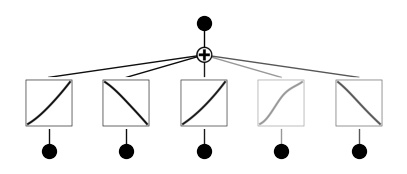

In [4]:
model = nexusKAN(width=[5, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [5]:
optimizer = optim.Adam(model.parameters(), lr=0.1)

In [6]:
criterion = nn.MSELoss()

batch_size = 512 # dataset['train_input'].shape[0]
epochs = 600

grid_update_freq = 150

for epoch in range(epochs):
    batches = dataset['train_input'].shape[0] // batch_size
    for batch_idx in range(batches):
        if batch_idx == batches - 1:
            indices = torch.arange(batch_idx * batch_size, dataset['train_input'].shape[0])
        else:
            indices = torch.arange(batch_idx * batch_size, (batch_idx + 1) * batch_size)
        
        batch_x = dataset['train_input'][indices]
        batch_y = dataset['train_label'][indices]
        
        # if epoch % grid_update_freq == 0:
        #     model.update_grid(batch_x)
        # if (epoch + 1) % grid_update_freq == 0:
        #     for param_group in optimizer.param_groups:
        #         param_group['lr'] *= 0.8
        
        outputs = model(batch_x)
        
        train_loss = criterion(outputs, batch_y)
        
        # reg = 0.0
        lamb = 0.00001
        l1_reg = sum(torch.norm(p, 1) for p in model.parameters())
        # l1_reg = sum(torch.norm(p, 0.5) for p in model.parameters())
        loss = train_loss + lamb * l1_reg
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        test_outputs = model(dataset['test_input'])
        test_loss = criterion(test_outputs, dataset['test_label'])
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}, reg: {l1_reg:.4f}')

Epoch [10/600], Train Loss: 0.1124, Test Loss: 0.1523, reg: 99.4284
Epoch [20/600], Train Loss: 0.0583, Test Loss: 0.0480, reg: 102.3082
Epoch [30/600], Train Loss: 0.0438, Test Loss: 0.0432, reg: 101.6720
Epoch [40/600], Train Loss: 0.0325, Test Loss: 0.0316, reg: 101.4351
Epoch [50/600], Train Loss: 0.0313, Test Loss: 0.0310, reg: 101.5803
Epoch [60/600], Train Loss: 0.0308, Test Loss: 0.0313, reg: 101.5617
Epoch [70/600], Train Loss: 0.0305, Test Loss: 0.0306, reg: 101.3925
Epoch [80/600], Train Loss: 0.0303, Test Loss: 0.0303, reg: 101.0440
Epoch [90/600], Train Loss: 0.0303, Test Loss: 0.0302, reg: 100.9295
Epoch [100/600], Train Loss: 0.0302, Test Loss: 0.0303, reg: 100.9028
Epoch [110/600], Train Loss: 0.0301, Test Loss: 0.0302, reg: 100.7064
Epoch [120/600], Train Loss: 0.0301, Test Loss: 0.0301, reg: 100.5319
Epoch [130/600], Train Loss: 0.0301, Test Loss: 0.0302, reg: 100.5188
Epoch [140/600], Train Loss: 0.0300, Test Loss: 0.0300, reg: 100.5338
Epoch [150/600], Train Loss: 0

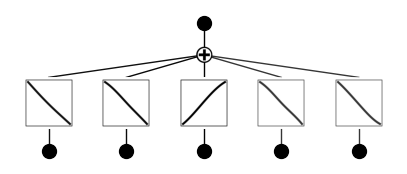

In [7]:
model.plot()

In [8]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

act_fun.0.coef tensor([[[-7.3675e-03, -1.2844e-02,  2.3607e-04,  7.0627e-01,  7.0953e-02,
          -4.1770e-01, -7.3022e-01, -1.0649e+00]],

        [[ 2.0595e-02,  8.9196e-03, -1.6065e-02,  1.7506e-02,  2.0489e-01,
          -4.8250e-01, -3.9290e-01, -4.9430e-01]],

        [[ 1.1850e-02, -5.3209e-03,  2.9903e-02,  1.0553e+00,  5.4027e-01,
          -3.2916e-01, -1.0309e+00, -1.1154e+00]],

        [[-8.6701e-03, -1.5090e-02,  9.4691e-03,  1.3915e-01,  2.3677e-01,
          -3.6971e-01, -2.4998e-01, -9.0913e-01]],

        [[ 1.0044e-02, -7.5565e-03,  8.0351e-03,  4.4683e-01,  1.4688e-01,
          -2.4103e-01, -3.7551e-01,  6.3838e-01]]], device='cuda:0')
act_fun.0.scale_base tensor([[-0.4369],
        [-1.1080],
        [ 0.0804],
        [-0.5537],
        [-0.5461]], device='cuda:0')
act_fun.0.scale_sp tensor([[ 0.5297],
        [ 0.2080],
        [-1.0762],
        [ 0.1710],
        [ 0.2167]], device='cuda:0')
act_fun.0.prod_group_mask tensor([[ 0.8985,  0.0347],
        [ 0.8